In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [5]:
df = pd.read_excel(fpath + '\\4.0_database_variables.xlsx')

In [6]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'weekday(1=free days)': 'weekday'})

In [7]:
# remove outliers
df = df[(np.abs(stats.zscore(df['sleep_duration(h)'])) < 3)]
df = df[(np.abs(stats.zscore(df['midpoint_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

_Descriptive statistics_

In [8]:
#rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

#rename the weekday column as 0=work days, 1=free days
df['weekday'] = df['weekday'].map({0: 'work days', 1: 'free days'})

In [9]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [10]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [11]:
df_grouped_weekday = df.groupby('weekday').describe()
df_grouped_weekday = df_grouped_weekday.transpose()

In [12]:
df_grouped_location_weekday = df.groupby(['location', 'weekday']).describe()
df_grouped_location_weekday = df_grouped_location_weekday.transpose()

In [13]:
#perfrom a t test to compare the midpoint, duration and phase between the two locations
ttest_midpoint_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midpoint_h'], df[df['location'] == 'UK']['midpoint_h'])
ttest_duration_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_duration(h)'], df[df['location'] == 'UK']['sleep_duration(h)'])
ttest_phase_loc = stats.ttest_ind(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'], df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'])

#perform a t test to compare the midpoint, duration and phase between work days and free days
ttest_midpoint_week = stats.ttest_ind(df[df['weekday'] == 'work days']['midpoint_h'], df[df['weekday'] == 'free days']['midpoint_h'])
ttest_duration_week = stats.ttest_ind(df[df['weekday'] == 'work days']['sleep_duration(h)'], df[df['weekday'] == 'free days']['sleep_duration(h)'])
ttest_phase_week = stats.ttest_ind(df[df['weekday'] == 'work days']['phase(sleepoffset-sunrise)'], df[df['weekday'] == 'free days']['phase(sleepoffset-sunrise)'])

In [14]:
# show the results of the t test
print('T test results for location')
print('Midpoint:', ttest_midpoint_loc)
print('Duration:', ttest_duration_loc)
print('Phase:', ttest_phase_loc)

T test results for location
Midpoint: TtestResult(statistic=2.6805139423138473, pvalue=0.0075662781488848386, df=563.0)
Duration: TtestResult(statistic=-1.0072447477170554, pvalue=0.31424987147222233, df=563.0)
Phase: TtestResult(statistic=-8.704627083984393, pvalue=3.527045932123219e-17, df=563.0)


In [15]:
print('T test results for weekday') 
print('Midpoint:', ttest_midpoint_week)
print('Duration:', ttest_duration_week)
print('Phase:', ttest_phase_week)

T test results for weekday
Midpoint: TtestResult(statistic=-9.50032089200523, pvalue=5.939401753000896e-20, df=563.0)
Duration: TtestResult(statistic=-2.98742829263595, pvalue=0.0029359053719122423, df=563.0)
Phase: TtestResult(statistic=-7.2442055565278, pvalue=1.4384766127159018e-12, df=563.0)


_Two-way ANOVA_

In [16]:
model_1 = ols('midpoint_h ~ C(location) * C(weekday)', data=df).fit()

In [17]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [18]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                              sum_sq     df             F        PR(>F)
Intercept               71090.857907    1.0  98545.463270  0.000000e+00
C(location)                 0.000713    1.0      0.000989  9.749257e-01
C(weekday)                 29.125550    1.0     40.373558  4.342691e-10
C(location):C(weekday)      1.959224    1.0      2.715858  9.991545e-02
Residual                  404.706315  561.0           NaN           NaN


_Tukey's multiple comparison test_

In [19]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['midpoint_h'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [20]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
ITA_free days ITA_work days  -0.6542    0.0 -0.9195 -0.3889   True
ITA_free days  UK_free days   0.0044    1.0 -0.3565  0.3653  False
ITA_free days  UK_work days  -0.9199    0.0 -1.2002 -0.6395   True
ITA_work days  UK_free days   0.6586    0.0  0.3427  0.9745   True
ITA_work days  UK_work days  -0.2657 0.0102 -0.4851 -0.0463   True
 UK_free days  UK_work days  -0.9243    0.0 -1.2529 -0.5957   True
------------------------------------------------------------------


_Assumption_

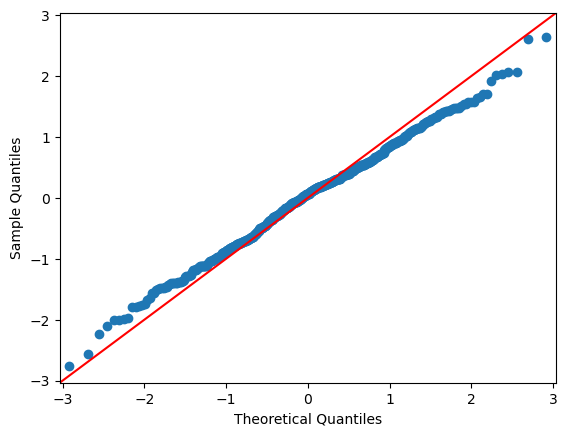

In [21]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_1.resid, line='45')
plt.show()

In [22]:
#detecting outliers
outliers = model_1.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.UK]  dfb_C(weekday)[T.work days]  \
198  -8.214732e-14          -3.126047e-01                 1.499256e-13   
187  -8.192180e-14          -2.555151e-01                 1.495140e-13   
45    0.000000e+00           2.510254e-01                 2.058128e-13   
263  -8.190417e-14           2.505135e-01                 1.386498e-13   
333  -8.187567e-14          -2.422073e-01                 1.429328e-13   
16   -4.093184e-14          -2.386282e-01                 1.981279e-13   
219  -8.179554e-14          -2.171857e-01                 1.352206e-13   
66   -2.742842e-01           1.706517e-01                 2.321582e-01   
106  -4.088360e-14           2.076214e-01                 2.065455e-13   
332  -8.174691e-14           2.004927e-01                 1.427081e-13   
256   2.486142e-01          -1.546805e-01                -2.104307e-01   
166   2.465499e-01          -1.533962e-01                -2.086834e-01   
402  -2.448228e-01           1.523216e

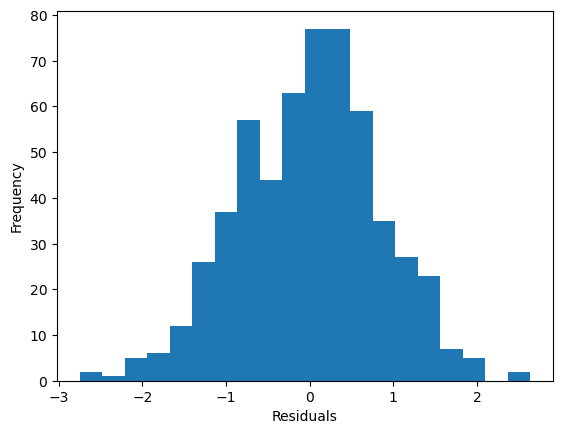

In [23]:
#frequency vs residuals
plt.hist(model_1.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [24]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_1.resid) 
print(w, pvalue)

0.9971190627346128 0.42437742104857146


_Plot results_

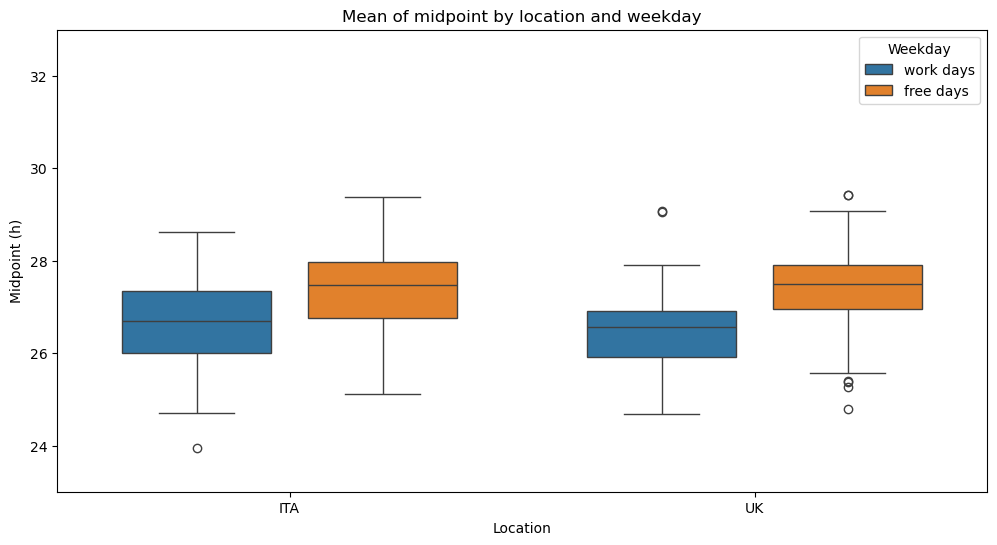

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h', hue='weekday', data=df, gap=0.2)
plt.title('Mean of midpoint by location and weekday')
plt.xlabel('Location')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h)')
plt.legend(title='Weekday')
plt.show()

------------------------------------------------------------------------------------

In [26]:
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})

_Two-way ANOVA_

In [27]:
model_2 = ols('sleep_duration ~ C(location) * C(weekday)', data=df).fit()

In [28]:
anova_results = sm.stats.anova_lm(model_2, typ=3)

In [29]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                             sum_sq     df            F         PR(>F)
Intercept               8091.479605    1.0  4919.756476  7.761513e-280
C(location)                0.414689    1.0     0.252138   6.157706e-01
C(weekday)                 9.393923    1.0     5.711664   1.718163e-02
C(location):C(weekday)     0.009030    1.0     0.005491   9.409583e-01
Residual                 922.671698  561.0          NaN            NaN


_Tukey's multiple comparison test_

In [30]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['sleep_duration'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [31]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------
ITA_free days ITA_work days  -0.3715 0.0802 -0.7721  0.029  False
ITA_free days  UK_free days   0.1062 0.9586 -0.4387 0.6511  False
ITA_free days  UK_work days   -0.247 0.4361 -0.6703 0.1763  False
ITA_work days  UK_free days   0.4777 0.0495  0.0007 0.9547   True
ITA_work days  UK_work days   0.1245 0.7673 -0.2067 0.4558  False
 UK_free days  UK_work days  -0.3532 0.2585 -0.8494  0.143  False
-----------------------------------------------------------------


_Assumption_

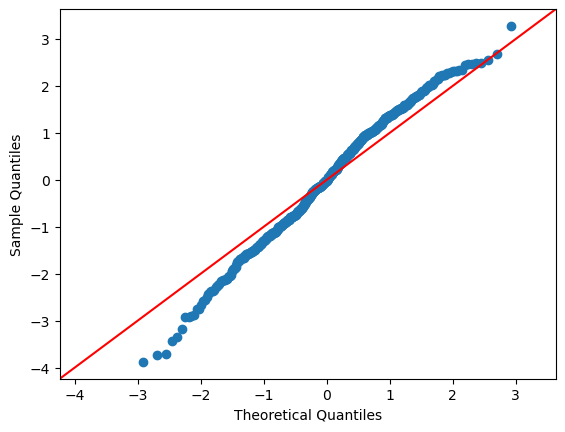

In [32]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_2.resid, line='45')
plt.show()

In [33]:
#detecting outliers
outliers = model_2.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.UK]  dfb_C(weekday)[T.work days]  \
499  -3.159561e-01           1.965788e-01                 2.674299e-01   
540  -3.021677e-01           1.880000e-01                 2.557592e-01   
235  -2.706250e-14          -1.922622e-01                 3.435914e-14   
395  -4.059106e-14          -1.902414e-01                 3.220957e-14   
403  -2.370374e-01           1.474778e-01                 2.006320e-01   
31   -2.370374e-01           1.474778e-01                 2.006320e-01   
396  -4.058320e-14          -1.841815e-01                 3.220333e-14   
174  -2.227123e-01           1.385652e-01                 1.885070e-01   
263  -2.704442e-14          -1.707273e-01                 3.075951e-14   
459   2.172971e-01          -1.351960e-01                -1.839235e-01   
424  -5.407844e-14          -1.640063e-01                 4.541519e-14   
431  -1.975274e-01           1.228958e-01                 1.671901e-01   
270  -2.703160e-14           1.536408e

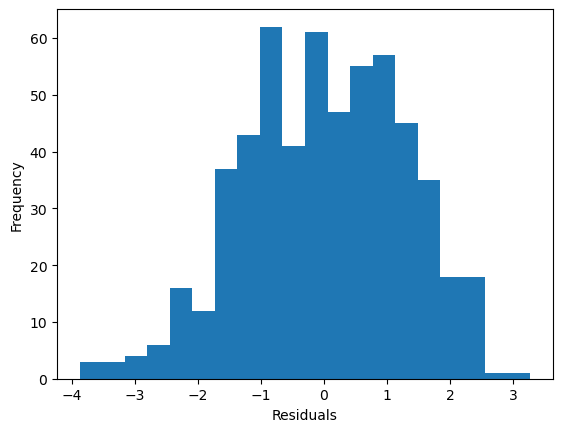

In [34]:
#frequency vs residuals
plt.hist(model_2.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [35]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_2.resid) 
print(w, pvalue)

0.9912014605336796 0.001931062288490526


_Plot results_

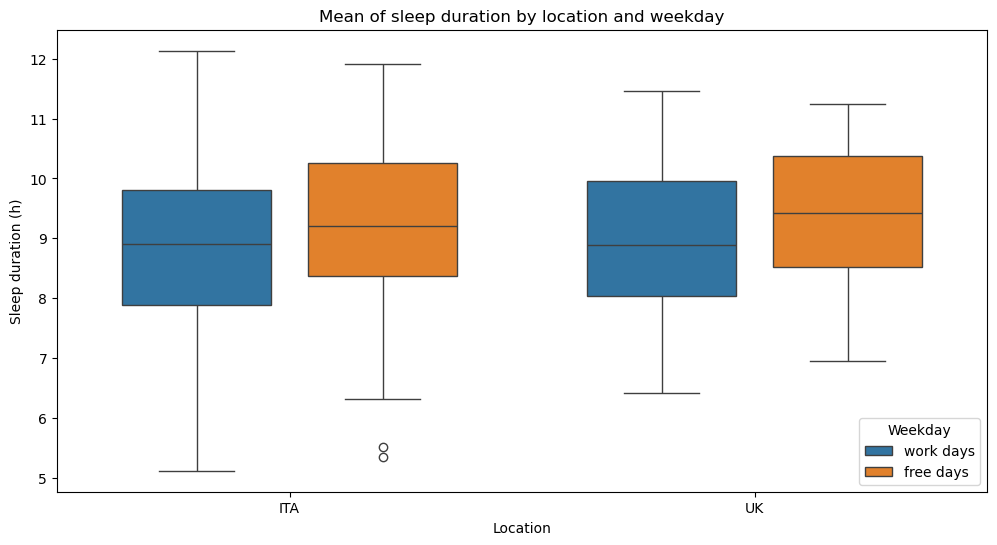

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='sleep_duration', hue='weekday', data=df, gap=0.2)
plt.title('Mean of sleep duration by location and weekday')
plt.xlabel('Location')
plt.ylim()
plt.ylabel('Sleep duration (h)')
plt.legend(title='Weekday')
plt.show()

------------------------------------------------------

In [37]:
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

_Two way ANOVA_

In [38]:
model_3 = ols('phase ~ C(location) * C(weekday)', data=df).fit()

In [39]:
anova_results = sm.stats.anova_lm(model_3, typ=3)

In [40]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                            sum_sq     df          F        PR(>F)
Intercept                 5.400237    1.0   3.586256  5.877359e-02
C(location)              32.988797    1.0  21.907605  3.591110e-06
C(weekday)               61.085467    1.0  40.566386  3.960816e-10
C(location):C(weekday)    0.071979    1.0   0.047800  8.270153e-01
Residual                844.762137  561.0        NaN           NaN


_Tukey's multiple comparison test_

In [41]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['phase'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [42]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
ITA_free days ITA_work days  -0.9474    0.0 -1.3307 -0.5641   True
ITA_free days  UK_free days   0.9471    0.0  0.4257  1.4686   True
ITA_free days  UK_work days   0.0515 0.9878 -0.3535  0.4566  False
ITA_work days  UK_free days   1.8945    0.0  1.4381  2.3509   True
ITA_work days  UK_work days   0.9989    0.0  0.6819  1.3159   True
 UK_free days  UK_work days  -0.8956    0.0 -1.3704 -0.4208   True
------------------------------------------------------------------


_Assumption_

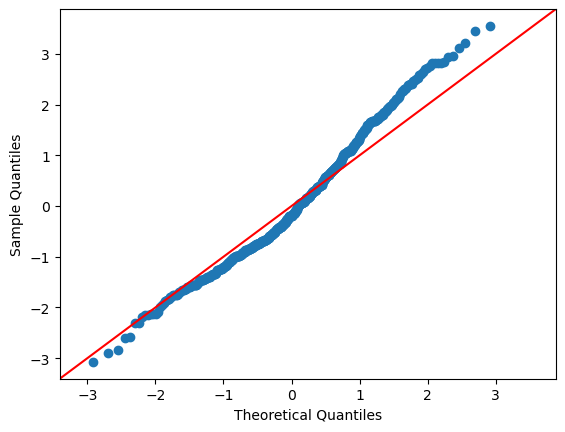

In [43]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_3.resid, line='45')
plt.show()

In [44]:
#detecting outliers
outliers = model_3.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.UK]  dfb_C(weekday)[T.work days]  \
235  -3.099416e-15          -2.441125e-01                 7.495405e-16   
533  -2.433562e-15           2.267584e-01                 1.498038e-15   
480  -2.654364e-15           2.225196e-01                 1.497795e-15   
333  -3.096390e-15          -2.193654e-01                 1.497617e-15   
16   -1.548073e-15          -2.172475e-01                 1.497499e-15   
487   2.728196e-01          -1.697404e-01                -2.309185e-01   
514   2.499182e-01          -1.554919e-01                -2.115344e-01   
507  -2.651641e-15           1.936071e-01                 7.481294e-16   
66   -2.407913e-01           1.498133e-01                 2.038093e-01   
521   2.399197e-01          -1.492711e-01                -2.030716e-01   
527  -2.429373e-15           1.767219e-01                 1.495460e-15   
216   4.438696e-16          -2.761628e-15                 3.005582e-15   
459   2.192459e-01          -1.364085e

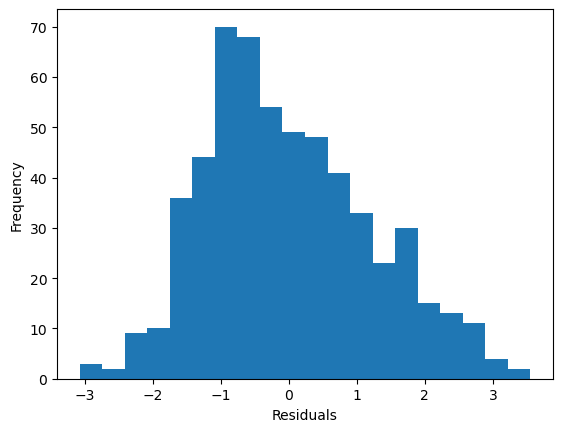

In [45]:
#frequency vs residuals
plt.hist(model_3.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [46]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_3.resid) 
print(w, pvalue)

0.9797411194220492 4.6713664046038e-07


_Plot results_

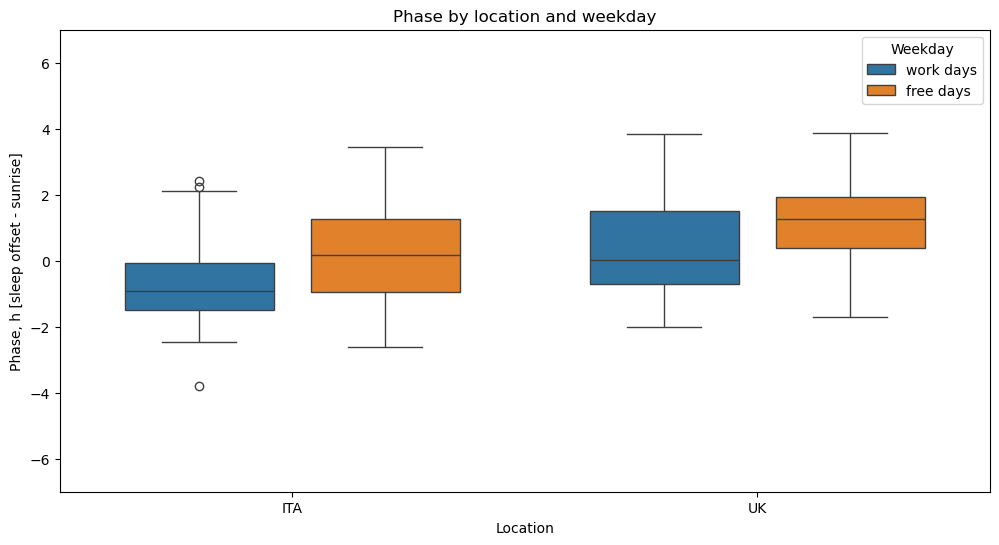

In [47]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday', data=df, gap=0.2)
plt.title('Phase by location and weekday')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend(title='Weekday')

plt.show()

----------------------------------------------------------------------------------

In [48]:
# check that the coulum "date" is datetime format
df['date'] = pd.to_datetime(df['date'])

In [49]:
df['week'] = df['date'].dt.isocalendar().week # add a variables: week number

In [50]:
# rename the columns
#df['weekday'] = df['weekday'].map({'work days': 0, 'free days': 1})
#df['location'] = df['location'].map({'ITA': 0, 'UK': 1})

In [51]:
data_jetlag = df

In [52]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week', 'weekday'])['midpoint_h'].mean().unstack()

In [53]:
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [54]:
# add a column with the location
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

In [55]:
# comparison jetlag between locations
#comparison_jetlag = weekly_means_jetlag.reset_index()

In [56]:
# Perform a t-test to compare the jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), 
                               weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

print('T test results for jet lag')
print(ttest_jetlag)

T test results for jet lag
TtestResult(statistic=0.5585215497020839, pvalue=0.579084575016124, df=48.0)


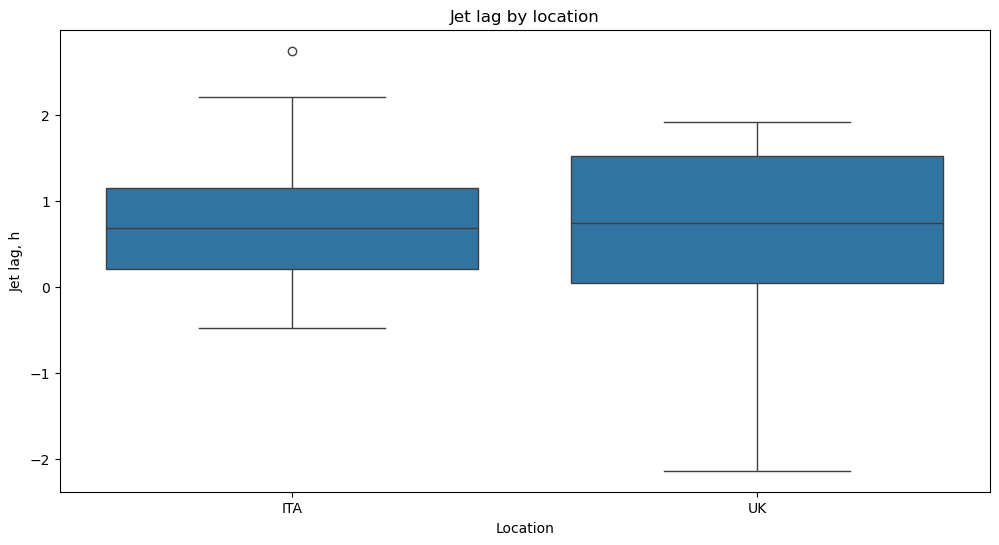

In [57]:
#plot the jet lag
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='jet lag', data=weekly_means_jetlag)
plt.title('Jet lag by location')
plt.xlabel('Location')
plt.ylabel('Jet lag, h')
plt.show()

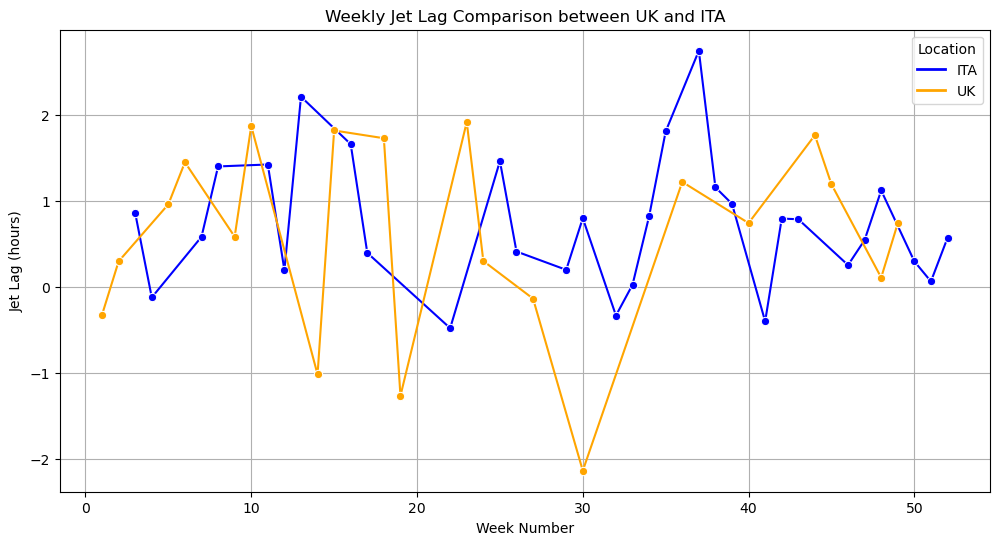

In [58]:
# Plot the weekly jet lag between UK and ITA
plt.figure(figsize=(12, 6))
sns.lineplot(x='week', y='jet lag', hue='location', data=weekly_means_jetlag, marker='o', palette=['blue', 'orange'])
plt.title('Weekly Jet Lag Comparison between UK and ITA')
plt.xlabel('Week Number')
plt.ylabel('Jet Lag (hours)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='blue', lw=2), plt.Line2D([0], [0], color='orange', lw=2)])
plt.grid(True)
plt.show()